In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold


In [26]:
from scipy.io import arff
import pandas as pd

# Path to your file (relative path — IMPORTANT for grading)
path = "../data/raw/mammography.arff"

# Load ARFF file
data, meta = arff.loadarff(path)

# Convert to DataFrame
df = pd.DataFrame(data)

# Preview
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,b'-1'
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,b'-1'
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,b'-1'
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,b'-1'
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,b'-1'


In [27]:
df['class'] = df['class'].str.decode('utf-8')

In [28]:
df['class'] = df['class'].astype(int)
df['class'] = df['class'].replace(-1, 0)

In [29]:
df.to_csv("../data/processed/mammography.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [30]:
print(df['class'].value_counts())

class
0    10923
1      260
Name: count, dtype: int64


In [31]:
df = pd.read_csv("../data/processed/mammography.csv")
df.columns

Index(['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'class'], dtype='object')

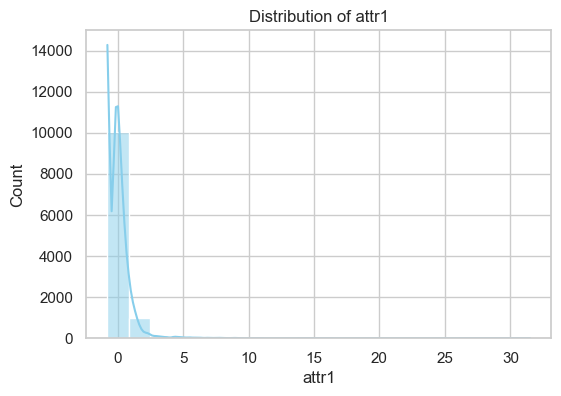

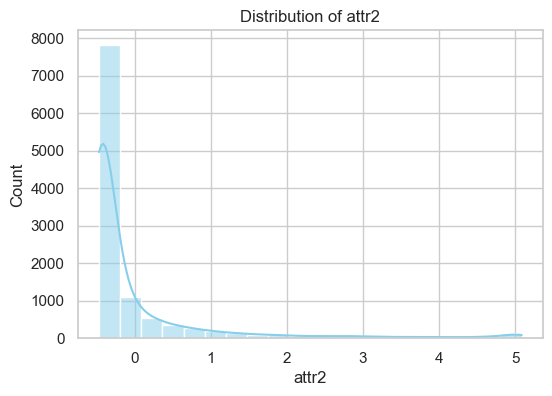

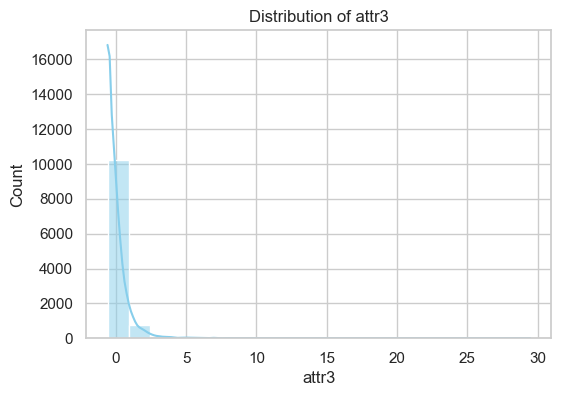

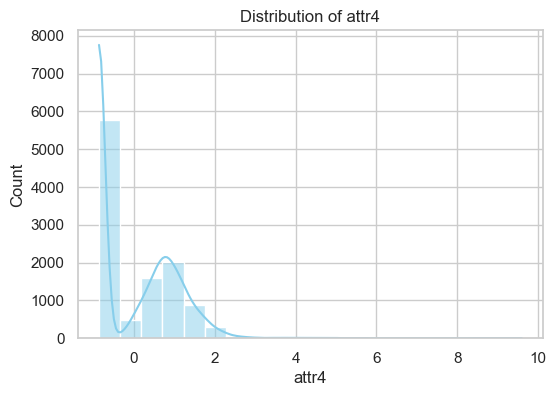

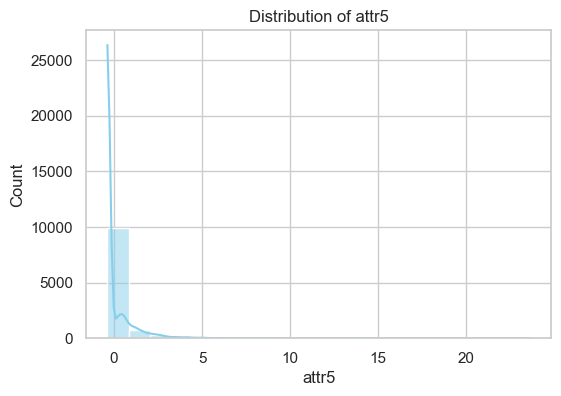

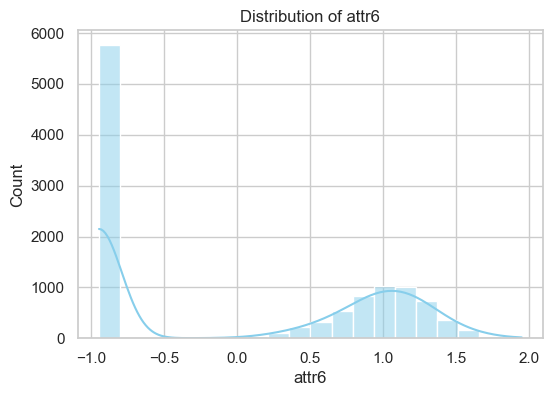

In [32]:
sns.set(style = "whitegrid")

continuous_features = ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
target = 'class'
#plot the historgrams for continous features 
for col in continuous_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

C:\Users\patrusgurung\AppData\Local\Temp\ipykernel_16404\4008742577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data= df, palette = "Set2" )


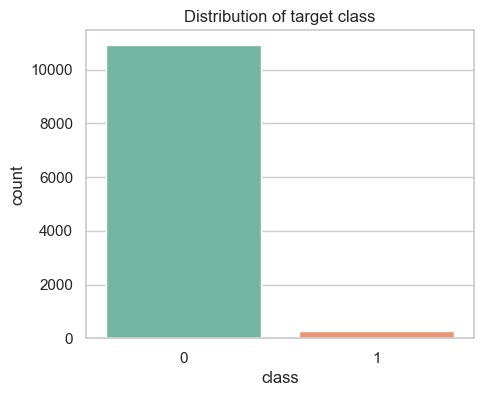

In [33]:
#plotting the target distrbution 
plt.figure(figsize=(5,4))
sns.countplot(x=target, data= df, palette = "Set2" )
plt.title('Distribution of target class')
plt.xlabel("class")
plt.ylabel("count")
plt.show()

In [34]:
#defining the numerical and categorical features 
X = df.drop('class', axis =1)
y = df['class']

#identify numerical and categoricla columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_fetures = X.select_dtypes(include= ['object']).columns.tolist()

In [35]:
#spliting into training and testing data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}") 

Training samples: 8946, Test samples: 2237


In [36]:
#building Column transformer 
numeric_features = X_train.columns.tolist()
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features)
    ]
)



In [37]:
#building the pipeline 
rf_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier( random_state=42, n_jobs=-1))

])

#evaluatin the CV 5 fold 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use F1 score since dataset is imbalanced
scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='f1')

print("5-Fold CV F1 scores:", scores)
print("Mean F1 score:", np.mean(scores))

5-Fold CV F1 scores: [0.68571429 0.64615385 0.71875    0.63636364 0.66666667]
Mean F1 score: 0.6707296869796869


In [38]:
#hyperparameter 
param_gris = {
    'classifier__n_estimators' : [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2,5],
    'classifier__min_samples_leaf': [1,2]
}



In [39]:
#3fold startified CV for fast 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best F1 score:", grid_search.best_score_)
print("Best hyperparameters:", grid_search.best_params_)

NameError: name 'param_grid' is not defined